In [1]:
# ============================================================================
# 🌠 DON'T LOOK UP: VISUALIZING APOCALYPSE
# Notebook 05: Advanced Interactive Visualizations
# ============================================================================
# Author: Abdullah Hasan Dafa (@hasandafa)
# GitHub: https://github.com/hasandafa/do-not-look-up
#
# "If we're going to track doomsday, we might as well make it pretty." 🎨☄️
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.style.use('dark_background')
sns.set_palette("husl")

print("=" * 80)
print("Making the apocalypse look good since 2025.")
print("=" * 80)

Making the apocalypse look good since 2025.


In [2]:
# ============================================================================
# PART 1: DATA LOADING & SETUP
# ============================================================================

print("📂 Loading engineered dataset...")
df = pd.read_csv('../data/processed/asteroid_dataset_engineered.csv')
df['close_approach_date'] = pd.to_datetime(df['close_approach_date'])

print(f"✅ Loaded {len(df):,} asteroid records")
print(f"📅 Date range: {df['close_approach_date'].min()} to {df['close_approach_date'].max()}\n")

# Create output directory
import os
os.makedirs('../data/visualizations', exist_ok=True)

# Color schemes
THREAT_COLORS = {
    'SAFE': '#4ade80',
    'MONITOR': '#fbbf24', 
    'CONCERN': '#fb923c',
    'OH_NO': '#ef4444'
}

PANIC_COLORSCALE = 'YlOrRd'

📂 Loading engineered dataset...
✅ Loaded 89,227 asteroid records
📅 Date range: 2020-01-01 00:54:00 to 2100-12-30 08:29:00



In [14]:
# ============================================================================
# PART 2: THE PANIC DASHBOARD (4-Panel Overview)
# ============================================================================

print("=" * 80)
print("📊 VIZ 1: THE PANIC DASHBOARD")
print("=" * 80)
print("Creating multi-panel threat overview...\n")

# Create subplots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Current Threat Level', 'Next 30 Days', 
                   'Risk Distribution', 'Top Threats'),
    specs=[[{'type': 'indicator'}, {'type': 'bar'}],
           [{'type': 'violin'}, {'type': 'table'}]],
    vertical_spacing=0.18,     # Increased from 0.12
    horizontal_spacing=0.12,   # Increased from 0.1
    row_heights=[0.4, 0.6]     # Give more space to bottom row
)

# Panel 1: Current Threat Gauge
today = pd.Timestamp.now()
next_30 = df[(df['close_approach_date'] >= today) & 
             (df['close_approach_date'] <= today + pd.Timedelta(days=30))]
current_max_panic = next_30['panic_level'].max() if len(next_30) > 0 else 0

gauge = go.Indicator(
    mode="gauge+number",
    value=current_max_panic,
    domain={'x': [0.1, 0.9], 'y': [0.15, 0.85]},  # Smaller domain with better padding
    title={'text': "Max Panic Level<br><sub>(Next 30 Days)</sub>", 
           'font': {'size': 12}},  # Smaller font
    number={'font': {'size': 36}},  # Smaller number
    gauge={
        'axis': {'range': [0, 10], 'tickwidth': 1, 'tickfont': {'size': 10}},
        'bar': {'color': "darkred", 'thickness': 0.6},
        'steps': [
            {'range': [0, 3], 'color': "#4ade80"},
            {'range': [3, 6], 'color': "#fbbf24"},
            {'range': [6, 8], 'color': "#fb923c"},
            {'range': [8, 10], 'color': "#ef4444"}
        ],
        'threshold': {
            'line': {'color': "white", 'width': 3},
            'thickness': 0.7,
            'value': current_max_panic
        }
    }
)

fig.add_trace(gauge, row=1, col=1)

# Panel 2: Next 30 Days Approaches
if len(next_30) > 0:
    daily_counts = next_30.set_index('close_approach_date').resample('D').size()
    fig.add_trace(
        go.Bar(
            x=daily_counts.index,
            y=daily_counts.values,
            marker_color='#60a5fa',
            name='Approaches'
        ),
        row=1, col=2
    )

# Panel 3: Risk Distribution (Violin Plot)
for category in ['SAFE', 'MONITOR', 'CONCERN', 'OH_NO']:
    cat_data = df[df['threat_category'] == category]['risk_score']
    fig.add_trace(
        go.Violin(
            y=cat_data,
            name=category,
            box_visible=True,
            meanline_visible=True,
            marker_color=THREAT_COLORS[category],
            opacity=0.7
        ),
        row=2, col=1
    )

# Panel 4: Top Threats Table
top_threats = df.nlargest(5, 'risk_score')[
    ['asteroid_designation', 'close_approach_date', 'distance_au', 
     'panic_level', 'threat_category']
].copy()
top_threats['close_approach_date'] = top_threats['close_approach_date'].dt.strftime('%Y-%m-%d')
top_threats['distance_au'] = top_threats['distance_au'].round(6)

fig.add_trace(
    go.Table(
        header=dict(
            values=['Asteroid', 'Date', 'Distance (AU)', 'Panic', 'Threat'],
            fill_color='#1e293b',
            font=dict(color='white', size=12),
            align='left'
        ),
        cells=dict(
            values=[top_threats[col] for col in top_threats.columns],
            fill_color='#0f172a',
            font=dict(color='white', size=11),
            align='left'
        )
    ),
    row=2, col=2
)

# Update layout
fig.update_layout(
    title={
        'text': "🌠 DON'T LOOK UP: Panic Dashboard",
        'font': {'size': 20},
        'x': 0.5,
        'xanchor': 'center',
        'y': 0.98,
        'yanchor': 'top'
    },
    showlegend=False,
    height=1000,  # Increased height significantly
    paper_bgcolor='#0a0a0a',
    plot_bgcolor='#0a0a0a',
    font=dict(color='white'),
    margin=dict(t=100, b=50, l=50, r=50)  # Add margins
)

# Update subplot titles position
for annotation in fig['layout']['annotations']:
    annotation['y'] = annotation['y'] + 0.05  # Move titles up slightly

# Save
fig.write_html('../data/visualizations/panic_dashboard.html')
print("✅ Saved: panic_dashboard.html")

fig.show()

📊 VIZ 1: THE PANIC DASHBOARD
Creating multi-panel threat overview...

✅ Saved: panic_dashboard.html


In [10]:
# ============================================================================
# PART 3: 3D SOLAR SYSTEM VISUALIZATION
# ============================================================================

print("\n" + "=" * 80)
print("🌌 VIZ 2: 3D SOLAR SYSTEM")
print("=" * 80)
print("Creating 3D asteroid visualization...\n")

# Sample data for performance (use all high-risk + random sample)
high_risk = df[df['panic_level'] >= 5]
low_risk_sample = df[df['panic_level'] < 5].sample(n=min(2000, len(df[df['panic_level'] < 5])), random_state=42)
viz_df = pd.concat([high_risk, low_risk_sample]).copy()

print(f"Using {len(viz_df):,} asteroids for visualization")

# Approximate 3D coordinates (simplified orbital mechanics)
# Using distance and velocity to create pseudo-orbital positions
np.random.seed(42)

# Convert to approximate Cartesian coordinates
# This is a simplified approximation - real orbital mechanics would need full ephemeris data
theta = np.random.uniform(0, 2*np.pi, len(viz_df))  # Orbital angle
phi = np.random.uniform(-np.pi/6, np.pi/6, len(viz_df))  # Inclination

viz_df['x'] = viz_df['distance_au'] * np.cos(theta) * np.cos(phi)
viz_df['y'] = viz_df['distance_au'] * np.sin(theta) * np.cos(phi)
viz_df['z'] = viz_df['distance_au'] * np.sin(phi)

# Create size array (based on absolute magnitude - brighter = larger)
# Handle NaN values in absolute_magnitude
# Make asteroids MUCH smaller so Earth is visible
sizes = (25 - viz_df['absolute_magnitude'].fillna(viz_df['absolute_magnitude'].median())) / 5  
sizes = sizes.clip(0.5, 4)  # Much smaller range: 0.5 to 4 (was 1 to 15)
sizes = sizes.fillna(2)  # Fill any remaining NaN with small default size

# Create hover text
hover_text = []
for idx, row in viz_df.iterrows():
    text = (
        f"<b>{row['asteroid_designation']}</b><br>" +
        f"Date: {row['close_approach_date']}<br>" +
        f"Distance: {row['distance_au']:.6f} AU<br>" +
        f"Velocity: {row['velocity_km_s']:.2f} km/s<br>" +
        f"Panic Level: {row['panic_level']}/10<br>" +
        f"Category: {row['threat_category']}"
    )
    hover_text.append(text)

# Create 3D scatter plot
fig = go.Figure()

# Add Earth at center - MUCH BIGGER
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers+text',
    name='Earth',
    marker=dict(
        size=25,  # Increased from 20
        color='#3b82f6',  # Brighter blue
        symbol='circle',
        line=dict(color='white', width=3)
    ),
    text=['🌍 EARTH'],
    textposition='top center',
    textfont=dict(size=14, color='white'),
    hovertext='🌍 Earth<br>Our home',
    hoverinfo='text'
))

# Add asteroids
fig.add_trace(go.Scatter3d(
    x=viz_df['x'],
    y=viz_df['y'],
    z=viz_df['z'],
    mode='markers',
    name='Asteroids',
    marker=dict(
        size=sizes,
        color=viz_df['panic_level'],
        colorscale=PANIC_COLORSCALE,
        showscale=True,
        colorbar=dict(
            title="Panic<br>Level",
            thickness=15,
            len=0.7
        ),
        line=dict(color='rgba(255,255,255,0.3)', width=0.5),
        opacity=0.8
    ),
    text=hover_text,
    hoverinfo='text'
))

# Update layout
fig.update_layout(
    title="🌌 Solar System Asteroid Distribution (Simplified Orbits)",
    scene=dict(
        xaxis=dict(
            title='X (AU)',
            backgroundcolor='black',
            gridcolor='#1e293b',
            showbackground=True,
            range=[-2, 2]  # Limit view range to see Earth better
        ),
        yaxis=dict(
            title='Y (AU)',
            backgroundcolor='black',
            gridcolor='#1e293b',
            showbackground=True,
            range=[-2, 2]
        ),
        zaxis=dict(
            title='Z (AU)',
            backgroundcolor='black',
            gridcolor='#1e293b',
            showbackground=True,
            range=[-0.5, 0.5]  # Smaller Z range
        ),
        bgcolor='black',
        camera=dict(
            eye=dict(x=1.2, y=1.2, z=0.8),  # Closer camera view
            center=dict(x=0, y=0, z=0)  # Focus on Earth
        ),
        aspectmode='cube'  # Equal aspect ratio
    ),
    paper_bgcolor='#0a0a0a',
    font=dict(color='white'),
    height=800,
    showlegend=True,
    legend=dict(
        x=0.85,
        y=0.95,
        bgcolor='rgba(0,0,0,0.7)',
        bordercolor='white',
        borderwidth=1
    )
)

# Save
fig.write_html('../data/visualizations/3d_solar_system.html')
print("✅ Saved: 3d_solar_system.html")

fig.show()


🌌 VIZ 2: 3D SOLAR SYSTEM
Creating 3D asteroid visualization...

Using 25,271 asteroids for visualization
✅ Saved: 3d_solar_system.html


In [15]:
# ============================================================================
# PART 4: APOCALYPSE CALENDAR HEATMAP
# ============================================================================

print("\n" + "=" * 80)
print("📅 VIZ 3: APOCALYPSE CALENDAR")
print("=" * 80)
print("Creating temporal threat heatmap...\n")

# Create year-month matrix
calendar_data = df.groupby(['year', 'month']).agg({
    'risk_score': 'max',
    'asteroid_designation': 'count'
}).reset_index()
calendar_data.columns = ['year', 'month', 'max_risk', 'count']

# Pivot for heatmap
heatmap_data = calendar_data.pivot(index='year', columns='month', values='max_risk')

# Create heatmap
fig = go.Figure(data=go.Heatmap(
    z=heatmap_data.values,
    x=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    y=heatmap_data.index,
    colorscale=PANIC_COLORSCALE,
    colorbar=dict(title="Max Risk<br>Score"),
    hovertemplate='Year: %{y}<br>Month: %{x}<br>Max Risk: %{z:.4f}<extra></extra>'
))

fig.update_layout(
    title="📅 Apocalypse Calendar: Maximum Monthly Threat (2020-2100)",
    xaxis_title="Month",
    yaxis_title="Year",
    height=800,
    paper_bgcolor='#0a0a0a',
    plot_bgcolor='#0a0a0a',
    font=dict(color='white')
)

# Save
fig.write_html('../data/visualizations/apocalypse_calendar.html')
print("✅ Saved: apocalypse_calendar.html")

fig.show()


📅 VIZ 3: APOCALYPSE CALENDAR
Creating temporal threat heatmap...

✅ Saved: apocalypse_calendar.html


In [17]:
# ============================================================================
# PART 5: VIZ 4 - DISTANCE VS VELOCITY ENHANCED
# ============================================================================

print("\n" + "=" * 80)
print("🎯 VIZ 4: DISTANCE VS VELOCITY (ENHANCED)")
print("=" * 80)
print("Creating interactive scatter plot...\n")

# Sample for performance
sample_df = df.sample(n=min(10000, len(df)), random_state=42).copy()

# ⬇️ FIX: Remove rows with NaN in absolute_magnitude
sample_df = sample_df.dropna(subset=['absolute_magnitude'])

fig = px.scatter(
    sample_df,
    x='distance_au',
    y='velocity_km_s',
    color='panic_level',
    size='absolute_magnitude',
    hover_data=['asteroid_designation', 'close_approach_date', 'threat_category'],
    color_continuous_scale=PANIC_COLORSCALE,
    title="🎯 Distance vs Velocity: The Danger Matrix",
    labels={
        'distance_au': 'Distance from Earth (AU)',
        'velocity_km_s': 'Relative Velocity (km/s)',
        'panic_level': 'Panic Level'
    }
)

# Add quadrant lines
median_dist = sample_df['distance_au'].median()
median_vel = sample_df['velocity_km_s'].median()

fig.add_hline(y=median_vel, line_dash="dash", line_color="cyan", 
              annotation_text="Median Velocity", annotation_position="right")
fig.add_vline(x=median_dist, line_dash="dash", line_color="cyan",
              annotation_text="Median Distance", annotation_position="top")

# Add annotations for quadrants
fig.add_annotation(
    x=0.02, y=sample_df['velocity_km_s'].max() * 0.95,
    text="⚠️ DANGER ZONE<br>(Close & Fast)",
    showarrow=False,
    font=dict(color="red", size=12, family="Arial Black"),
    bgcolor="rgba(239, 68, 68, 0.3)",
    bordercolor="red",
    borderwidth=2
)

fig.add_annotation(
    x=sample_df['distance_au'].quantile(0.9), y=5,
    text="🟢 CHILL ZONE<br>(Far & Slow)",
    showarrow=False,
    font=dict(color="green", size=12, family="Arial Black"),
    bgcolor="rgba(74, 222, 128, 0.3)",
    bordercolor="green",
    borderwidth=2
)

fig.update_layout(
    height=700,
    paper_bgcolor='#0a0a0a',
    plot_bgcolor='#0f172a',
    font=dict(color='white')
)

# Save
fig.write_html('../data/visualizations/distance_velocity_scatter.html')
print("✅ Saved: distance_velocity_scatter.html")

fig.show()


🎯 VIZ 4: DISTANCE VS VELOCITY (ENHANCED)
Creating interactive scatter plot...

✅ Saved: distance_velocity_scatter.html


In [18]:
# ============================================================================
# PART 6: THREAT EVOLUTION TIMELINE
# ============================================================================

print("\n" + "=" * 80)
print("📈 VIZ 5: THREAT EVOLUTION TIMELINE")
print("=" * 80)
print("Creating temporal trend analysis...\n")

# Aggregate by year
yearly_stats = df.groupby('year').agg({
    'asteroid_designation': 'count',
    'risk_score': ['mean', 'max'],
    'panic_level': 'max',
    'on_sentry_list': 'sum'
}).reset_index()

yearly_stats.columns = ['year', 'count', 'avg_risk', 'max_risk', 'max_panic', 'sentry_count']

# Create multi-line plot
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Asteroid Approach Frequency', 'Risk Metrics Over Time'),
    vertical_spacing=0.15,
    specs=[[{"secondary_y": False}], [{"secondary_y": True}]]
)

# Plot 1: Count
fig.add_trace(
    go.Scatter(
        x=yearly_stats['year'],
        y=yearly_stats['count'],
        mode='lines+markers',
        name='Approach Count',
        line=dict(color='#60a5fa', width=3),
        fill='tozeroy',
        fillcolor='rgba(96, 165, 250, 0.3)'
    ),
    row=1, col=1
)

# Plot 2: Risk metrics
fig.add_trace(
    go.Scatter(
        x=yearly_stats['year'],
        y=yearly_stats['avg_risk'],
        mode='lines+markers',
        name='Avg Risk Score',
        line=dict(color='#fbbf24', width=2)
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=yearly_stats['year'],
        y=yearly_stats['max_risk'],
        mode='lines+markers',
        name='Max Risk Score',
        line=dict(color='#ef4444', width=2, dash='dash')
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=yearly_stats['year'],
        y=yearly_stats['max_panic'],
        mode='lines+markers',
        name='Max Panic Level',
        line=dict(color='#a78bfa', width=2),
        yaxis='y3'
    ),
    row=2, col=1,
    secondary_y=True
)

# Update axes
fig.update_xaxes(title_text="Year", row=1, col=1)
fig.update_xaxes(title_text="Year", row=2, col=1)
fig.update_yaxes(title_text="Number of Approaches", row=1, col=1)
fig.update_yaxes(title_text="Risk Score", row=2, col=1)
fig.update_yaxes(title_text="Panic Level", secondary_y=True, row=2, col=1)

fig.update_layout(
    title_text="📈 Asteroid Threat Evolution (2020-2100)",
    height=800,
    paper_bgcolor='#0a0a0a',
    plot_bgcolor='#0f172a',
    font=dict(color='white'),
    hovermode='x unified'
)

# Save
fig.write_html('../data/visualizations/threat_timeline.html')
print("✅ Saved: threat_timeline.html")

fig.show()


📈 VIZ 5: THREAT EVOLUTION TIMELINE
Creating temporal trend analysis...

✅ Saved: threat_timeline.html



📸 VIZ 6: STATIC SUMMARY GRAPHICS
Creating ready images...

✅ Saved: summary_graphic.png


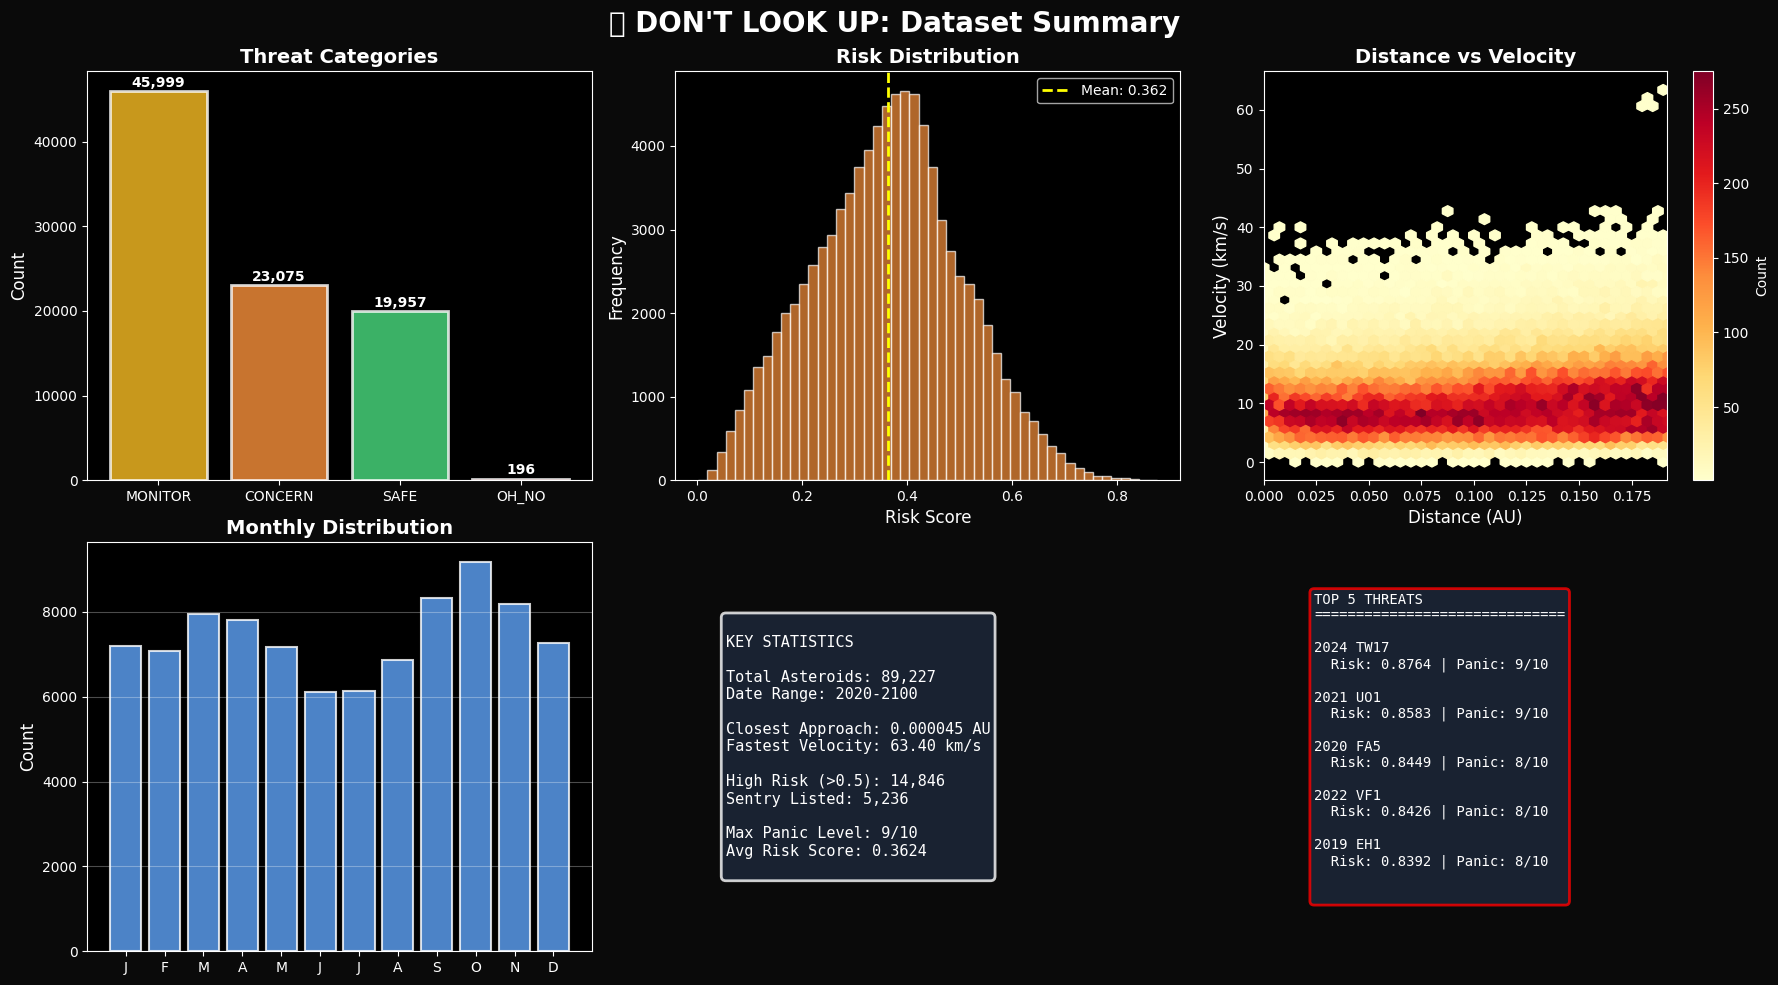

In [20]:
# ============================================================================
# PART 7: STATIC SUMMARY GRAPHICS
# ============================================================================

print("\n" + "=" * 80)
print("📸 VIZ 6: STATIC SUMMARY GRAPHICS")
print("=" * 80)
print("Creating ready images...\n")

# Create a comprehensive summary figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0a0a0a')
fig.suptitle('🌠 DON\'T LOOK UP: Dataset Summary', 
             fontsize=20, fontweight='bold', color='white')

# Plot 1: Threat Category Distribution
ax1 = axes[0, 0]
threat_counts = df['threat_category'].value_counts()
colors_list = [THREAT_COLORS[cat] for cat in threat_counts.index]
ax1.bar(threat_counts.index, threat_counts.values, color=colors_list, alpha=0.8, edgecolor='white', linewidth=2)
ax1.set_ylabel('Count', color='white', fontsize=12)
ax1.set_title('Threat Categories', color='white', fontsize=14, fontweight='bold')
ax1.tick_params(colors='white')
for i, v in enumerate(threat_counts.values):
    ax1.text(i, v + 500, f'{v:,}', ha='center', color='white', fontweight='bold')

# Plot 2: Risk Score Distribution
ax2 = axes[0, 1]
ax2.hist(df['risk_score'], bins=50, color='#fb923c', alpha=0.7, edgecolor='white')
ax2.axvline(df['risk_score'].mean(), color='yellow', linestyle='--', linewidth=2, label=f'Mean: {df["risk_score"].mean():.3f}')
ax2.set_xlabel('Risk Score', color='white', fontsize=12)
ax2.set_ylabel('Frequency', color='white', fontsize=12)
ax2.set_title('Risk Distribution', color='white', fontsize=14, fontweight='bold')
ax2.legend()
ax2.tick_params(colors='white')

# Plot 3: Velocity vs Distance (Density)
ax3 = axes[0, 2]
h = ax3.hexbin(df['distance_au'], df['velocity_km_s'], gridsize=40, cmap='YlOrRd', mincnt=1)
ax3.set_xlabel('Distance (AU)', color='white', fontsize=12)
ax3.set_ylabel('Velocity (km/s)', color='white', fontsize=12)
ax3.set_title('Distance vs Velocity', color='white', fontsize=14, fontweight='bold')
ax3.set_xlim(0, df['distance_au'].quantile(0.95))
plt.colorbar(h, ax=ax3, label='Count')
ax3.tick_params(colors='white')

# Plot 4: Monthly Distribution
ax4 = axes[1, 0]
monthly = df['month'].value_counts().sort_index()
month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
ax4.bar(range(1, 13), [monthly.get(i, 0) for i in range(1, 13)], 
        color='#60a5fa', alpha=0.8, edgecolor='white', linewidth=1.5)
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(month_names)
ax4.set_ylabel('Count', color='white', fontsize=12)
ax4.set_title('Monthly Distribution', color='white', fontsize=14, fontweight='bold')
ax4.tick_params(colors='white')
ax4.grid(alpha=0.3, axis='y')

# Plot 5: Key Statistics Table
ax5 = axes[1, 1]
ax5.axis('off')
stats_text = f"""
KEY STATISTICS

Total Asteroids: {len(df):,}
Date Range: {df['year'].min()}-{df['year'].max()}

Closest Approach: {df['distance_au'].min():.6f} AU
Fastest Velocity: {df['velocity_km_s'].max():.2f} km/s

High Risk (>0.5): {(df['risk_score'] > 0.5).sum():,}
Sentry Listed: {df['on_sentry_list'].sum():,}

Max Panic Level: {df['panic_level'].max()}/10
Avg Risk Score: {df['risk_score'].mean():.4f}
"""
ax5.text(0.1, 0.5, stats_text, fontsize=11, color='white', 
         family='monospace', verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='#1e293b', alpha=0.8, edgecolor='white', linewidth=2))

# Plot 6: Top 5 Threats
ax6 = axes[1, 2]
ax6.axis('off')
top5 = df.nlargest(5, 'risk_score')[['asteroid_designation', 'risk_score', 'panic_level']]
table_text = "TOP 5 THREATS\n" + "="*30 + "\n\n"
for idx, row in top5.iterrows():
    table_text += f"{row['asteroid_designation'][:15]:15s}\n"
    table_text += f"  Risk: {row['risk_score']:.4f} | Panic: {row['panic_level']}/10\n\n"

ax6.text(0.1, 0.5, table_text, fontsize=10, color='white',
         family='monospace', verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='#1e293b', alpha=0.8, edgecolor='red', linewidth=2))

plt.tight_layout()
plt.savefig('../data/visualizations/summary_graphic.png', dpi=300, facecolor='#0a0a0a')
print("✅ Saved: summary_graphic.png")
plt.show()

In [21]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("🎉 NOTEBOOK 05 COMPLETE!")
print("=" * 80)

print("\n📊 VISUALIZATIONS CREATED:")
print("  ✅ Panic Dashboard (4-panel interactive)")
print("  ✅ 3D Solar System (orbital visualization)")
print("  ✅ Apocalypse Calendar (year-month heatmap)")
print("  ✅ Distance vs Velocity (enhanced scatter)")
print("  ✅ Threat Timeline (temporal evolution)")
print("  ✅ Summary Graphic")

print("\n💾 FILES SAVED:")
print("  • panic_dashboard.html")
print("  • 3d_solar_system.html")
print("  • apocalypse_calendar.html")
print("  • distance_velocity_scatter.html")
print("  • threat_timeline.html")
print("  • summary_graphic.png")

print("\n🎯 NEXT STEPS:")
print("  → Build Gradio application")
print("  → Integrate all visualizations")
print("  → Deploy to Hugging Face Spaces")

print("\n" + "=" * 80)
print("The data is now beautiful AND terrifying. Mission accomplished.")
print("=" * 80)


🎉 NOTEBOOK 05 COMPLETE!

📊 VISUALIZATIONS CREATED:
  ✅ Panic Dashboard (4-panel interactive)
  ✅ 3D Solar System (orbital visualization)
  ✅ Apocalypse Calendar (year-month heatmap)
  ✅ Distance vs Velocity (enhanced scatter)
  ✅ Threat Timeline (temporal evolution)
  ✅ Summary Graphic

💾 FILES SAVED:
  • panic_dashboard.html
  • 3d_solar_system.html
  • apocalypse_calendar.html
  • distance_velocity_scatter.html
  • threat_timeline.html
  • summary_graphic.png

🎯 NEXT STEPS:
  → Build Gradio application
  → Integrate all visualizations
  → Deploy to Hugging Face Spaces

The data is now beautiful AND terrifying. Mission accomplished.
